[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Task 10.3

In [1]:
#import sys
#import os
#cur_fol = os.getcwd()
# print(cur_fol)
#sys.path.append(cur_fol + '/../')

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import sympy as sp
from scipy.signal import tf2zpk, dlti
from scipy.signal import TransferFunction, ZerosPolesGain, bilinear
from scipy.signal import dimpulse, dstep, dfreqresp, dbode
from scipy.fftpack import fft

#from sig_sys_tools import zplane_plot
from scipy.special import diric

In [2]:
Nf = 2**10  # values along frequency axis
Om = np.arange(-Nf, Nf) * (2*np.pi/Nf)  # get frequency vector for bode, fft


def plot_rect_psinc():
    plt.figure(figsize=(8, 6))
    ax = plt.subplot(2, 2, 1)
    plt.stem(k, x, use_line_collection=True,
             linefmt='C0:', markerfmt='C0o', basefmt='C0:')
    plt.stem(k+N, x*0, use_line_collection=True,
             linefmt='C0:', markerfmt='C0o', basefmt='C0:')
    plt.stem(k-N, x*0, use_line_collection=True,
             linefmt='C0:', markerfmt='C0o', basefmt='C0:')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlabel(r'$k$')
    plt.ylabel(r'$x[k]$')
    plt.grid(True)
    plt.subplot(2, 2, 2)
    plt.plot(Om, np.abs(X))
    plt.xlim(-2*np.pi, +2*np.pi)
    plt.xticks(np.arange(-4, 5)*np.pi/2,
               [r'$-2\pi$', r'$-\frac{3\pi}{2}$', r'$-\pi$', r'$-\frac{\pi}{2}$',
                r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])
    plt.xlabel(r'$\Omega$')
    plt.ylabel(r'$|X(\Omega)|$')
    plt.grid(True)
    plt.subplot(2, 2, 3)
    plt.plot(Om, np.real(X), label=r'$\Re\{X(\Omega)\}$')
    plt.plot(Om, np.imag(X), label=r'$\Im\{X(\Omega)\}$')
    plt.xlim(-2*np.pi, +2*np.pi)
    plt.xticks(np.arange(-4, 5)*np.pi/2,
               [r'$-2\pi$', r'$-\frac{3\pi}{2}$', r'$-\pi$', r'$-\frac{\pi}{2}$',
                r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])
    plt.xlabel(r'$\Omega$')
    plt.legend()
    plt.grid(True)
    plt.subplot(2, 2, 4)
    plt.plot(Om, np.unwrap(np.angle(X))*180/np.pi)
    plt.xlim(-2*np.pi, +2*np.pi)
    plt.xticks(np.arange(-4, 5)*np.pi/2,
               [r'$-2\pi$', r'$-\frac{3\pi}{2}$', r'$-\pi$', r'$-\frac{\pi}{2}$',
                r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])
    plt.ylim(-180, +180)
    plt.yticks(np.arange(-180, 180+45, 45))
    plt.grid(True)
    plt.xlabel(r'$\Omega$')
    plt.ylabel(r'$\angle X(\Omega)$ / deg')
    plt.tight_layout()

# Rect4 vs. Periodic Sinc Linearphase

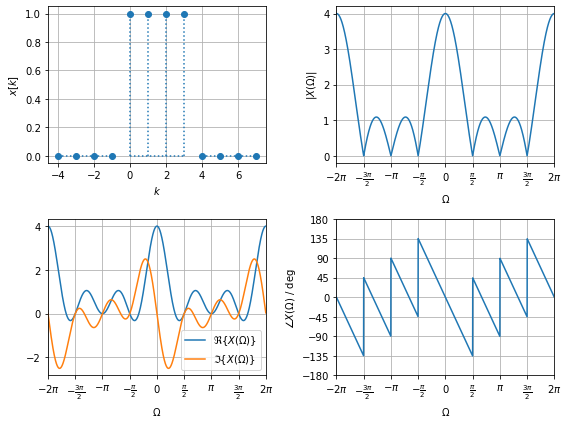

In [3]:
N = 4
kappa = -(N-1)/2
kappa = 0

x = np.ones(N)
k = np.arange(N) + kappa
X = diric(Om, N)*N * np.exp(-1j*Om*(N-1)/2) * np.exp(-1j*Om*kappa)
plot_rect_psinc()
plt.savefig('psinc_767B4C89FE_N4_linphase.pdf')

# Rect5 vs. Periodic Sinc Linearphase

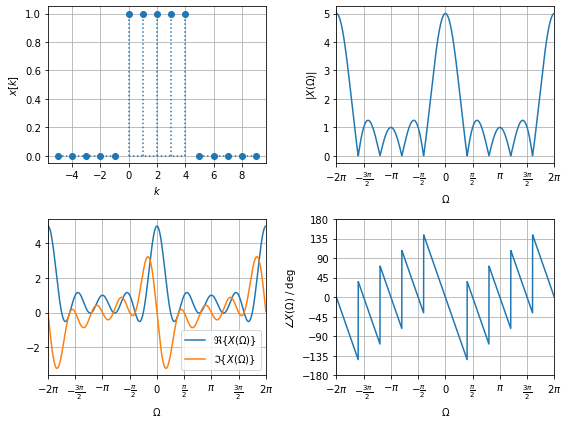

In [4]:
N = 5
kappa = -(N-1)/2
kappa = 0

x = np.ones(N)
k = np.arange(N) + kappa
X = diric(Om, N)*N * np.exp(-1j*Om*(N-1)/2) * np.exp(-1j*Om*kappa)
plot_rect_psinc()
plt.savefig('psinc_767B4C89FE_N5_linphase.pdf')

# Rect5 vs. Periodic Sinc Zerophase

-2.0


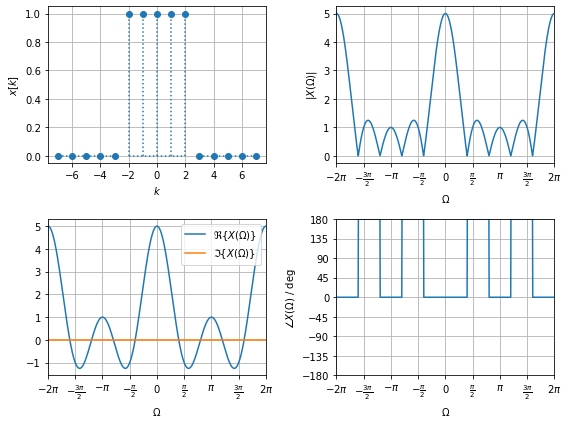

In [5]:
N = 5
kappa = -(N-1)/2
#kappa = 0
print(kappa)
x = np.ones(N)
k = np.arange(N) + kappa
X = diric(Om, N)*N * np.exp(-1j*Om*(N-1)/2) * np.exp(-1j*Om*kappa)
plot_rect_psinc()
plt.savefig('psinc_767B4C89FE_N5_zerophase.pdf')

# Rect31 vs. Periodic Sinc Zerophase

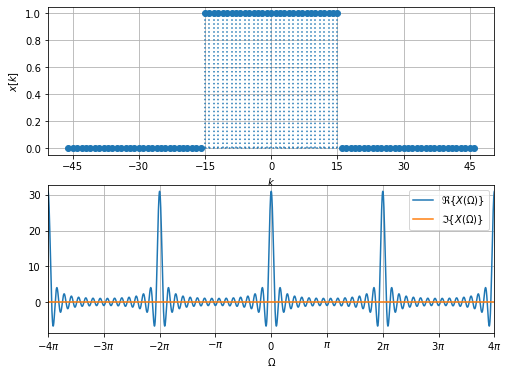

In [6]:
Om = np.arange(-2*Nf, 2*Nf) * (2*np.pi/Nf)

N = 31
kappa = -(N-1)/2
#kappa = 0

x = np.ones(N)
k = np.arange(N) + kappa
X = diric(Om, N)*N * np.exp(-1j*Om*(N-1)/2) * np.exp(-1j*Om*kappa)

plt.figure(figsize=(8, 6))
ax = plt.subplot(2, 1, 1)
plt.stem(k, x, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.stem(k+N, x*0, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.stem(k-N, x*0, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel(r'$k$')
plt.ylabel(r'$x[k]$')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(Om, np.real(X), label=r'$\Re\{X(\Omega)\}$')
plt.plot(Om, np.imag(X), label=r'$\Im\{X(\Omega)\}$')
plt.xlim(-4*np.pi, +4*np.pi)
plt.xticks(np.arange(-4, 5)*np.pi,
           [r'$-4\pi$', r'$-3\pi$', r'$-2\pi$', r'$-\pi$', r'$0$',
            r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$'])
plt.xlabel(r'$\Omega$')
plt.legend()
plt.grid(True)
plt.savefig('psinc_767B4C89FE_N31_zerophase.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.